In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("../data/Bengaluru_House_Data.csv")

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
# Dataset shape
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nInfo:")
df.info()

Shape: (13320, 9)

Columns:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [4]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

society     5502
balcony      609
bath          73
size          16
location       1
dtype: int64


In [5]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


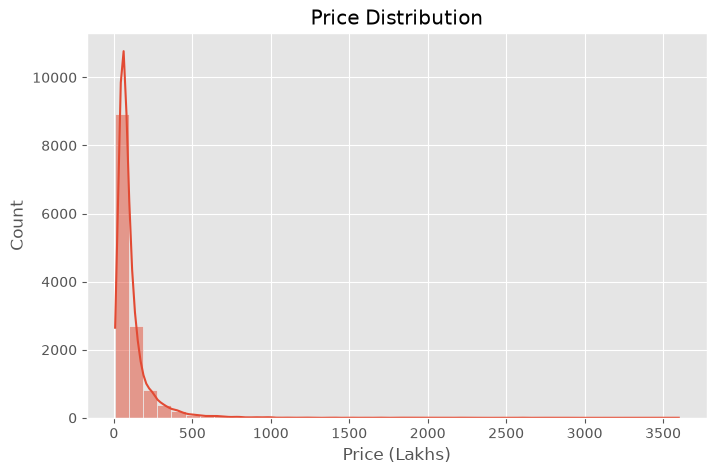

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=40, kde=True)

plt.title("Price Distribution")
plt.xlabel("Price (Lakhs)")
plt.show()

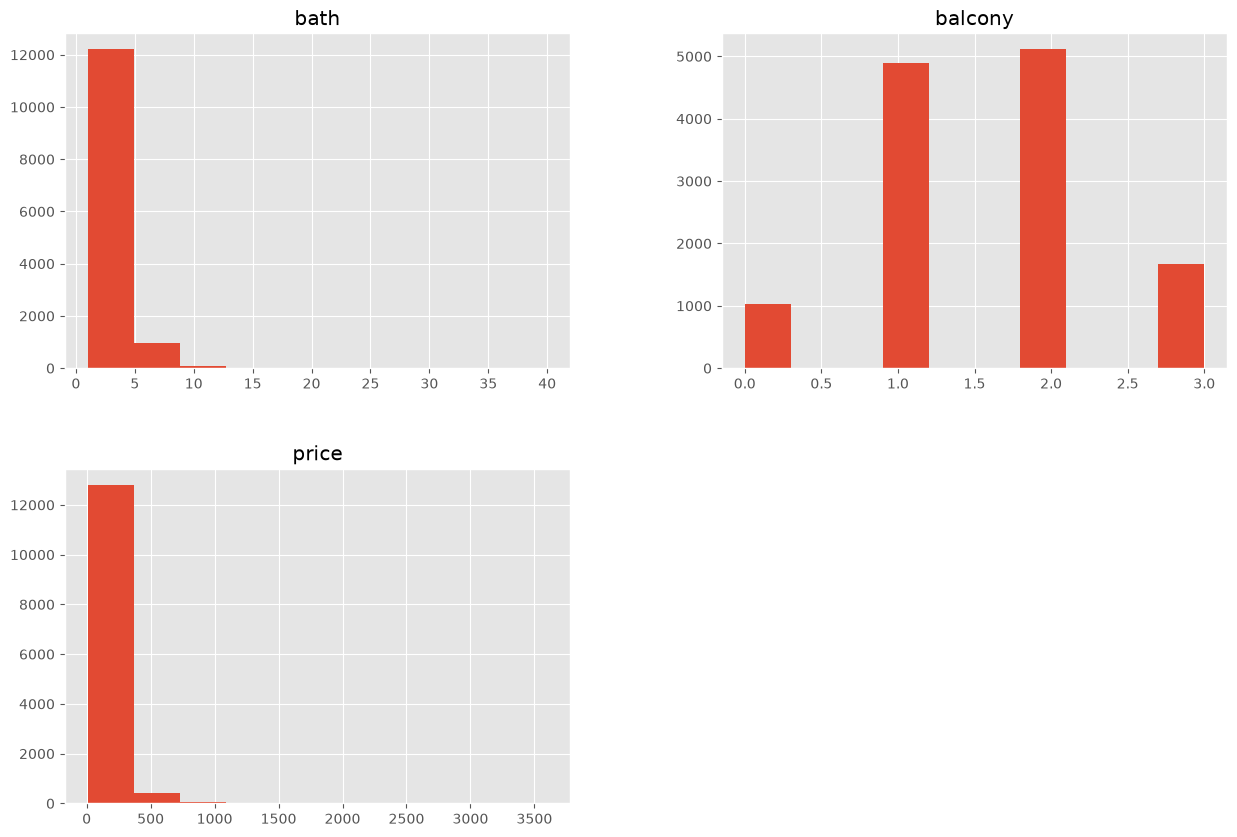

In [7]:
df.hist(figsize=(15,10))
plt.show()

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 529


In [9]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check the new shape
print("New Shape:", df.shape)

New Shape: (12791, 9)


In [10]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

society     5328
balcony      605
bath          73
size          16
location       1
dtype: int64

In [11]:
df = df.drop("society", axis=1)

print(df.shape)

(12791, 8)


In [12]:
df = df.dropna(subset=["size", "location"])

print(df.shape)

(12774, 8)


In [13]:
df["bath"] = df["bath"].fillna(df["bath"].median())
df["balcony"] = df["balcony"].fillna(df["balcony"].median())

In [14]:
print(df.isnull().sum())

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64


In [15]:
# Extract the number from the 'size' column
df["bhk"] = df["size"].apply(lambda x: int(x.split(" ")[0]))

# Check the result
df[["size", "bhk"]].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


In [16]:
df["total_sqft"].unique()[:20]

<StringArray>
['1056', '2600', '1440', '1521', '1200', '1170', '2732', '3300', '1310',
 '1020', '1800', '2785', '1000', '1100', '2250', '1175', '1180', '1540',
 '2770',  '600']
Length: 20, dtype: str

In [17]:
def convert_sqft_to_num(x):
    tokens = str(x).split("-")

    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2

    try:
        return float(x)
    except:
        return None

In [18]:
df["total_sqft"] = df["total_sqft"].apply(convert_sqft_to_num)

# Check missing values after conversion
print(df["total_sqft"].isnull().sum())

46


In [19]:
df = df.dropna(subset=["total_sqft"])

print(df.shape)

(12728, 9)


In [20]:
df[["size", "bhk"]].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


In [21]:
print(df.shape)

(12728, 9)


In [22]:
# Price per square foot
df["price_per_sqft"] = (df["price"] * 100000) / df["total_sqft"]

df[["total_sqft", "price", "price_per_sqft"]].head()

,total_sqft,price,price_per_sqft
0,1056.0,39.07,3699.810606
1,2600.0,120.00,4615.384615
2,1440.0,62.00,4305.555556
3,1521.0,95.00,6245.890861
4,1200.0,51.00,4250.000000


In [23]:
# Remove extra spaces
df["location"] = df["location"].apply(lambda x: x.strip())

# Number of unique locations
len(df["location"].unique())

1287

In [24]:
location_stats = df.groupby("location")["location"].count().sort_values(ascending=False)

location_stats.head(20)

location
Whitefield                  521
Sarjapur  Road              377
Electronic City             289
Kanakpura Road              247
Thanisandra                 231
Yelahanka                   209
Marathahalli                169
Hebbal                      161
Raja Rajeshwari Nagar       159
Uttarahalli                 157
Hennur Road                 149
Bannerghatta Road           148
7th Phase JP Nagar          134
Electronic City Phase II    128
Rajaji Nagar                107
Haralur Road                102
Bellandur                    93
KR Puram                     91
Hoodi                        88
Electronics City Phase 1     88
Name: location, dtype: int64

In [25]:
location_stats_less_than_10 = location_stats[location_stats <= 10]

len(location_stats_less_than_10)

1055

In [26]:
df["location"] = df["location"].apply(
    lambda x: "other" if x in location_stats_less_than_10 else x
)

len(df["location"].unique())

233

In [27]:
df[df["total_sqft"] / df["bhk"] < 300].head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft
9,Plot Area,Ready To Move,other,6 Bedroom,1020.0,6.0,2.0,370.0,6,36274.509804
45,Plot Area,Ready To Move,HSR Layout,8 Bedroom,600.0,9.0,2.0,200.0,8,33333.333333
58,Plot Area,Ready To Move,Murugeshpalya,6 Bedroom,1407.0,4.0,1.0,150.0,6,10660.980810
68,Plot Area,Ready To Move,Devarachikkanahalli,8 Bedroom,1350.0,7.0,0.0,85.0,8,6296.296296
70,Plot Area,Ready To Move,other,3 Bedroom,500.0,3.0,2.0,100.0,3,20000.000000


In [28]:
df[df["total_sqft"] / df["bhk"] < 300].shape

(734, 10)

In [29]:
df = df[df["total_sqft"] / df["bhk"] >= 300]

print(df.shape)

(11994, 10)


In [30]:
df[df["total_sqft"] / df["bhk"] < 300].shape

(0, 10)

In [31]:
print(df.shape)

(11994, 10)


In [32]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()

    for key, subdf in df.groupby("location"):
        mean = np.mean(subdf.price_per_sqft)
        std = np.std(subdf.price_per_sqft)

        reduced_df = subdf[
            (subdf.price_per_sqft >= (mean - std)) &
            (subdf.price_per_sqft <= (mean + std))
        ]

        df_out = pd.concat([df_out, reduced_df], ignore_index=True)

    return df_out

In [33]:
df = remove_pps_outliers(df)

print(df.shape)

(9885, 10)


In [34]:
df = df.drop(["size", "price_per_sqft"], axis=1)

df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,20-May,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4
1,Super built-up Area,18-Jun,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3
2,Super built-up Area,Ready To Move,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3
3,Built-up Area,15-Dec,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3
4,Super built-up Area,18-Jun,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9885 entries, 0 to 9884
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     9885 non-null   str    
 1   availability  9885 non-null   str    
 2   location      9885 non-null   str    
 3   total_sqft    9885 non-null   float64
 4   bath          9885 non-null   float64
 5   balcony       9885 non-null   float64
 6   price         9885 non-null   float64
 7   bhk           9885 non-null   int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 617.9 KB


In [36]:
df = df.drop(["area_type", "availability"], axis=1)

df.head()

,location,total_sqft,bath,balcony,price,bhk
0,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2


In [37]:
dummies = pd.get_dummies(df.location)

dummies.head()

,1st Block Jayanagar,1st Phase JP Nagar,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,AECS Layout,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [38]:
df = pd.concat([df, dummies], axis=1)

df.head()

,location,total_sqft,bath,balcony,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [39]:
df = df.drop("location", axis=1)

df.head()

,total_sqft,bath,balcony,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,2850.0,4.0,1.0,428.0,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,2.0,194.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3.0,235.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,0.0,130.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2.0,148.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [40]:
X = df.drop("price", axis=1)
y = df["price"]

In [41]:
print(X.shape)
print(y.shape)

(9885, 237)
(9885,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
print(X_train.shape)
print(X_test.shape)

(7908, 237)
(1977, 237)


In [44]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](237,)","[ 0.07, 9.45, -1.13,...,-31.1 , -4.68, -1.58]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](237,)","['total_sqft','bath','balcony',...,'Yelenahalli','Yeshwanthpur','other']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-15.15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,237
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(236)


In [45]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ -2.49525667,  60.98156621,  19.27292042,  52.24645596,
        60.87810917, 192.74554691,  76.10991128,  64.18490672,
        73.39799003,  48.75183199])

In [46]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.7971486962399237
MAE      : 19.869417580477496
RMSE     : 35.06421478602125


In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [48]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ -2.49525667  60.98156621  19.27292042  52.24645596  60.87810917
 192.74554691  76.10991128  64.18490672  73.39799003  48.75183199]


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score : 0.7971486962399237
MAE      : 19.869417580477496
RMSE     : 35.06421478602125


In [50]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(model, "model/house_price_model.pkl")
joblib.dump(X.columns.tolist(), "model/columns.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
